In [6]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.feature as cfeature
from cartopy.feature import NaturalEarthFeature
import cartopy.crs as ccrs
from shapely.geometry import Point
import geopandas as gpd
import matplotlib as mpl
import matplotlib.colors as mcolors

In [7]:
def create_trends_colormap(cmap, bin_number, end_cutoffs, norm=True, season=None):
    """
    Creates a custom colormap with specified binning and optional normalization.

    Args:
        cmap (str): The name of the colormap to use.
        bin_number (int): The number of bins for the colormap.
        end_cutoffs (int): The number of bins to cut off from each end of the colormap.
        norm (bool, optional): Whether to normalize the colormap. Defaults to True.
        season (str, optional): If provided, adjusts the bin edges for seasonal data. Defaults to None.

    Returns:
        custom_cmap, norm (tuple): A tuple containing the custom colormap and the normalization object if norm is True.
        custom_cmap (ListedColormap): The custom colormap if norm is False.
    """
    if norm:
        middle_bins = np.array([-0.3666, -0.2333, -0.1, 0.1, 0.2333, 0.3666])
        # middle_bins = np.array([-0.3, -0.1, 0.1, 0.3])
        positive_end = np.arange(0.5, 2.166667, 0.166667)
        negative_end = np.sort(positive_end * (-1))
        bin_edges = np.concatenate((negative_end, middle_bins, positive_end))
        if season is not None:
            bin_edges = bin_edges/4

        bin_number = len(bin_edges) - 1

    brewer_cmap = mpl.colormaps[cmap]
    extra_bin_number = bin_number + (end_cutoffs * 4)
    colors_array = brewer_cmap(np.linspace(0, 1, extra_bin_number))
    grey_RGB = 230
    grey_color = [grey_RGB/255, grey_RGB/255, grey_RGB/255, 1]

    # Remove the very light colors close to zero to give extra contrast and super dark ones at the ends
    first_half_colors = colors_array[: extra_bin_number // 2][end_cutoffs:-end_cutoffs]
    second_half_colors = colors_array[extra_bin_number // 2 :][end_cutoffs:-end_cutoffs]
    new_colors_array = np.vstack([first_half_colors, grey_color, second_half_colors])

    custom_cmap = mcolors.ListedColormap(new_colors_array)

    if norm:
        norm = mcolors.BoundaryNorm(bin_edges, ncolors=bin_number, clip=False)
        
        return custom_cmap, norm
    else:
        return custom_cmap
    

def plot_MK_trendtest_single(ds, varname=None, year_label=None, cbar=True, cbar_lim=None, impacts=False, wheat_belt_only=False, plot_wheat_belt=False):
    """
    Plots a single xarray Dataset with MK_slope and MK_trend.
    Adds hatching for significance, masks with AGCD, supports mean/variability contributions and impact plots.
    Args:
        ds (xr.Dataset): Dataset with variables 'MK_slope' and 'MK_trend'
        varname (str): Optional name for setting title and colorbar logic (e.g., 'soil_moisture_drought_mean_contribution')
        year_label (str): Optional label to show on side of plot (e.g., '1951–2020')
        cbar (bool): Whether to include colorbar
        cbar_lim (float): Limit for colorbar range (symmetric)
        impacts (bool): Whether this is an impact-based variable (affects colormap)
    """
    mpl.rcParams['hatch.linewidth'] = 0.35

    if wheat_belt_only:
        plot_wheat_belt = True
        # wheatbelt_path = '/srv/ccrc/LandAU/z5459957/data/wheat_belt/'
        wheatbelt_path = '/g/data/w97/mg5624/ABS_project/ag_data/wheatbelt_shapefiles/'
        wheat_path = wheatbelt_path + 'wheatbelt.nc'
        wheat = xr.open_dataset(wheat_path)
        wheat = wheat.interp_like(ds, method='nearest')
        ds = ds.where(wheat.astype(bool))

    da = ds.MK_slope
    trend = ds.MK_trend

    AGCD_mask = xr.open_dataarray('/g/data/w97/mg5624/RF_project/masks/regridded_awra_awap_mask.nc')
    da = da.where(AGCD_mask)
    trend = trend.where(AGCD_mask)

    significant = (trend != 0) | (da != 0)
    trend_masked = trend.where(~significant)

    fig, ax = plt.subplots(1, 1, figsize=(8, 5), subplot_kw={'projection': ccrs.PlateCarree()})

    for spine in ax.spines.values():
        spine.set_visible(False)

    # Choose colormap
    if 'frost' in varname:
        # cmap = sns.color_palette("RdBu", as_cmap=True)
        cmap = create_trends_colormap('RdBu', 30, 3, norm=False)
        norm = None
        if cbar_lim is None:
            cbar_max = float(da.max().round(2))
            cbar_min = -cbar_max
        else:
            cbar_max = cbar_lim
            cbar_min = -cbar_max
    elif 'heatwave' in varname:
        cmap = create_trends_colormap('RdBu_r', 30, 3, norm=False)
        # cmap = sns.color_palette("RdBu_r", as_cmap=True)
        norm = None
        if cbar_lim is None:
            cbar_max = float(da.max().round(2))
            cbar_min = -cbar_max
        else:
            cbar_max = cbar_lim
            cbar_min = -cbar_max
    elif varname and 'drought' in varname or impacts:
        cmap = create_trends_colormap('BrBG_r', 30, 3, norm=False)
        # cmap = 'BrBG_r'
        norm = None
        if cbar_lim is None:
            cbar_max = float(da.max().round(2))
            cbar_min = -cbar_max
        else:
            cbar_max = cbar_lim
            cbar_min = -cbar_max
    else:
        # cmap, norm = create_trends_colormap('BrBG', 30, 3)
        cmap = 'BrBG'
        if cbar_lim is None:
            cbar_max = float(da.max().round(2))
            cbar_min = -cbar_max
        else:
            cbar_max = cbar_lim
            cbar_min = -cbar_max

    # Plot main field
    plot = da.plot(ax=ax, cmap=cmap, vmin=cbar_min, vmax=cbar_max, add_colorbar=False)

    # Plot hatching for non-significant trends
    trend_masked.plot.contourf(ax=ax, hatches=[5*'/'], colors='none',
                               levels=(0.5, 1), add_colorbar=False)

    # Add white ocean + boundaries
    ax.add_feature(cfeature.OCEAN, zorder=100, facecolor='white', edgecolor='k')
    states_provinces = NaturalEarthFeature(category='cultural',
                                           name='admin_1_states_provinces_lines',
                                           scale='50m',
                                           edgecolor='black',
                                           facecolor='none',
                                           alpha=0.5)
    ax.add_feature(states_provinces, linestyle='-', linewidth=1)

    # Format colorbar
    if cbar:
        cbar_ax = fig.add_axes([0.1, 0.08, 0.8, 0.03])
        if norm:
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        else:
            sm = plt.cm.ScalarMappable(cmap=cmap)
        sm.set_array([])
        sm.set_clim(vmin=cbar_min, vmax=cbar_max)

        cbar_obj = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal', extend='both')
        cbar_obj.ax.tick_params(labelsize=12)

        if varname == 'frost':
            cbar_obj.set_label('Change in no. of frost days per decade', fontsize=14)
        elif varname == 'heatwave':
            cbar_obj.set_label('Change in no. of heatwave days per decade', fontsize=14)
        elif 'drought' in varname:
            cbar_obj.set_label('Change in no. of drought days per decade', fontsize=14)

    # Optional label (year)
    if year_label:
        fig.text(0.015, 0.5, year_label, va='center', rotation='vertical', fontsize=14)

    if plot_wheat_belt:
        wheatbelt_path = '/g/data/w97/mg5624/ABS_project/ag_data/wheatbelt_shapefiles/'
        # SEA_wheat_path = wheatbelt_path + 'Agriculture_Wheatbelt_SEA_one_polygon.shp'
        # WA_wheat_path = wheatbelt_path + 'Agriculture_Wheatbelt_WA_one_polygon.shp'
        # SEA_wheat = gpd.read_file(SEA_wheat_path)
        # WA_wheat = gpd.read_file(WA_wheat_path)
        wheat_path = wheatbelt_path + 'wheatbelt.shp'
        wheat = gpd.read_file(wheat_path)
        wheat.plot(ax=ax, facecolor='none', edgecolor='darkgreen', linewidth=0.8)   # chocolate color
        # WA_wheat.plot(ax=ax, facecolor='none', edgecolor='darkgreen', linewidth=0.8)   # chocolate color
        # SEA_wheat.plot(ax=ax, facecolor='none', edgecolor='darkgreen', linewidth=0.8)

    # Optional title
    if varname:
        row_titles_dict = {
            'frost': 'No. of Frost Days',
            '180_day_precip_drought_intensity_mean': '180-day Precip Drought Intensity',
            '30_day_precip_drought_intensity_mean': '30-day Precip Drought Intensity',
            '180_day_precip_drought': 'No. of 180-day Precip Drought Days',
            '30_day_precip_drought': 'No. of 30-day Precip Drought Days',
            'heatwave_intensity_mean': 'Heatwave Intensity',
            'heatwave': 'No. of Heatwave Days'
        }
        ax.set_title(row_titles_dict.get(varname, varname), fontsize=22)

    plt.tight_layout(rect=[0.02, 0.15, 0.95, 0.95])
    plt.show()


In [8]:
def regrid_mask(mask, grid):
    """
    Regrids a given mask to match the grid of another dataset.

    Parameters:
    mask (xarray.DataArray): The mask to be regridded. It should have latitude ('lat') as one of its dimensions.
    grid (xarray.DataArray): The target grid to which the mask will be regridded.

    Returns:
    xarray.DataArray: The regridded mask with the same dimensions as the input grid, converted to boolean type.
    """
    mask = mask.sortby('lat')
    mask = mask.astype(int)
    regridded_mask = mask.interp_like(grid, method='nearest')

    # Build bounding-box mask
    lat_min = float(mask.lat.min())
    lat_max = float(mask.lat.max())
    lon_min = float(mask.lon.min())
    lon_max = float(mask.lon.max())

    # Boolean mask: True where grid is inside original mask domain
    inside = (
        (grid.lat >= lat_min) & (grid.lat <= lat_max) &
        (grid.lon >= lon_min) & (grid.lon <= lon_max)
    )

    # Force outside-domain points to False
    regridded_mask = regridded_mask.where(inside, 0)
    new_mask = regridded_mask.astype(bool)

    new_mask = regridded_mask.astype(bool)

    return new_mask

In [9]:
agcd_datadir = '/g/data/zv2/agcd/v1-0-1/precip/total/r005/01day/'
grid = xr.open_dataset(agcd_datadir + 'agcd_v1-0-1_precip_total_r005_daily_2016.nc').precip.isel(time=-50)
grid = grid.reset_coords(drop=True)

datadir = '/g/data/w97/mg5624/ABS_project/'
def load_crop_growing_season_and_regrid(crop, target_grid):
    crop_calendar_path = f'{datadir}crop_calendar/{crop}.crop.calendar.nc'
    crop_calendar = xr.open_dataset(crop_calendar_path)
    
    crop_calendar = crop_calendar.sel(latitude=slice(-7, -45), longitude=slice(110, 155))
    crop_calendar = crop_calendar.rename({'latitude': 'lat', 'longitude': 'lon'})
    crop_calendar = crop_calendar.interp_like(target_grid, method='nearest')
    # Fill in missing values
    crop_calendar_filled = crop_calendar.interpolate_na(dim='lat', method='nearest', fill_value='extrapolate')
    crop_calendar_filled = crop_calendar_filled.interpolate_na(dim='lon', method='nearest', fill_value='extrapolate')
    crop_calendar_ls_mask = crop_calendar_filled.where(~np.isnan(target_grid))
    return crop_calendar_ls_mask

crop_calendar = load_crop_growing_season_and_regrid('Wheat', grid)


def distance_between_days(start_day, end_day, leap_year=False):
    wrap_around = start_day > end_day
    distance = xr.where(
        wrap_around,
        (365 - start_day + 1) + end_day,  # e.g., Dec 31 (365) to Jan 1 (1) is 2 days
        end_day - start_day + 1
    )

    # Adjust for leap year: add 1 if day 60 (Feb 29) is in the range
    if leap_year:
        # Check if 60 falls between start and end, considering wrap
        contains_60 = xr.where(
            wrap_around,
            (start_day <= 60) | (end_day >= 60),
            (start_day <= 60) & (end_day >= 60)
        )
        distance += contains_60.astype(int)
    return distance

/scratch/w97/mg5624/tmp/ipykernel_3202067/559095840.py:8: FutureWarning: In a future version, xarray will not decode the variable 'harvest.range' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  crop_calendar = xr.open_dataset(crop_calendar_path)
/scratch/w97/mg5624/tmp/ipykernel_3202067/559095840.py:8: FutureWarning: In a future version, xarray will not decode the variable 'plant.range' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is

In [10]:
def len_of_season(crop_calendar, season):
    """
    Finds length of season across Australia.

    Args:
    crop_calendar (xr.Dataset): crop calendar for crop in question
        season (str): season to find length of ('growing', 'planting', 'mid', 'harvest')
    """
    start_of_season = crop_calendar['plant']
    season_len = distance_between_days(
        start_of_season,
        crop_calendar['harvest']
    )
    if season == 'growing':
        return season_len
    
    tercile_len = np.floor(season_len / 3)
    # start_of_season = crop_calendar['plant.start']
    start_of_mid = start_of_season + tercile_len + 1
    if season == 'planting':
        season_len = distance_between_days(start_of_season, start_of_mid)
        return season_len
    start_of_harvest = start_of_season + (2 * tercile_len) + 1
    if season == 'mid':
        season_len = distance_between_days(start_of_mid, start_of_harvest)
        return season_len
    if season == 'harvest':
        end_of_season = crop_calendar['harvest']
        season_len = distance_between_days(start_of_harvest, end_of_season)
        return season_len
    print(f'Season: {season}, not appropriate name for season')

/scratch/w97/mg5624/tmp/ipykernel_3202067/559095840.py:8: FutureWarning: In a future version, xarray will not decode the variable 'harvest.range' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  crop_calendar = xr.open_dataset(crop_calendar_path)
/scratch/w97/mg5624/tmp/ipykernel_3202067/559095840.py:8: FutureWarning: In a future version, xarray will not decode the variable 'plant.range' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is

Max trend for 30_day_precip_drought_sum in growing: 7.05
Max trend for 30_day_precip_drought_sum in planting: 2.59
Max trend for 30_day_precip_drought_sum in mid: 2.86
Max trend for 30_day_precip_drought_sum in harvest: 2.86
Max trend for heatwave_intensity_mean in growing: 3.68
Max trend for heatwave_intensity_mean in mid: 4.39
Max trend for heatwave_intensity_mean in harvest: 3.68
Max trend for frost in growing: 4.29
Max trend for frost in planting: 1.67
Max trend for frost in mid: 2.43
------------ Percentage trends for 30_day_precip_drought_sum in growing ------------
Full wheat belt: 71.70%
WA wheat belt: 66.60%
Eastern wheat belt: 73.10%
------------ Percentage trends for heatwave_intensity_mean in growing ------------
Full wheat belt: 92.20%
WA wheat belt: 84.63%
Eastern wheat belt: 94.28%
------------ Percentage trends for frost in growing ------------
Full wheat belt: 36.80%
WA wheat belt: 22.07%
Eastern wheat belt: 40.84%
------------ Percentage trends for 30_day_precip_droug

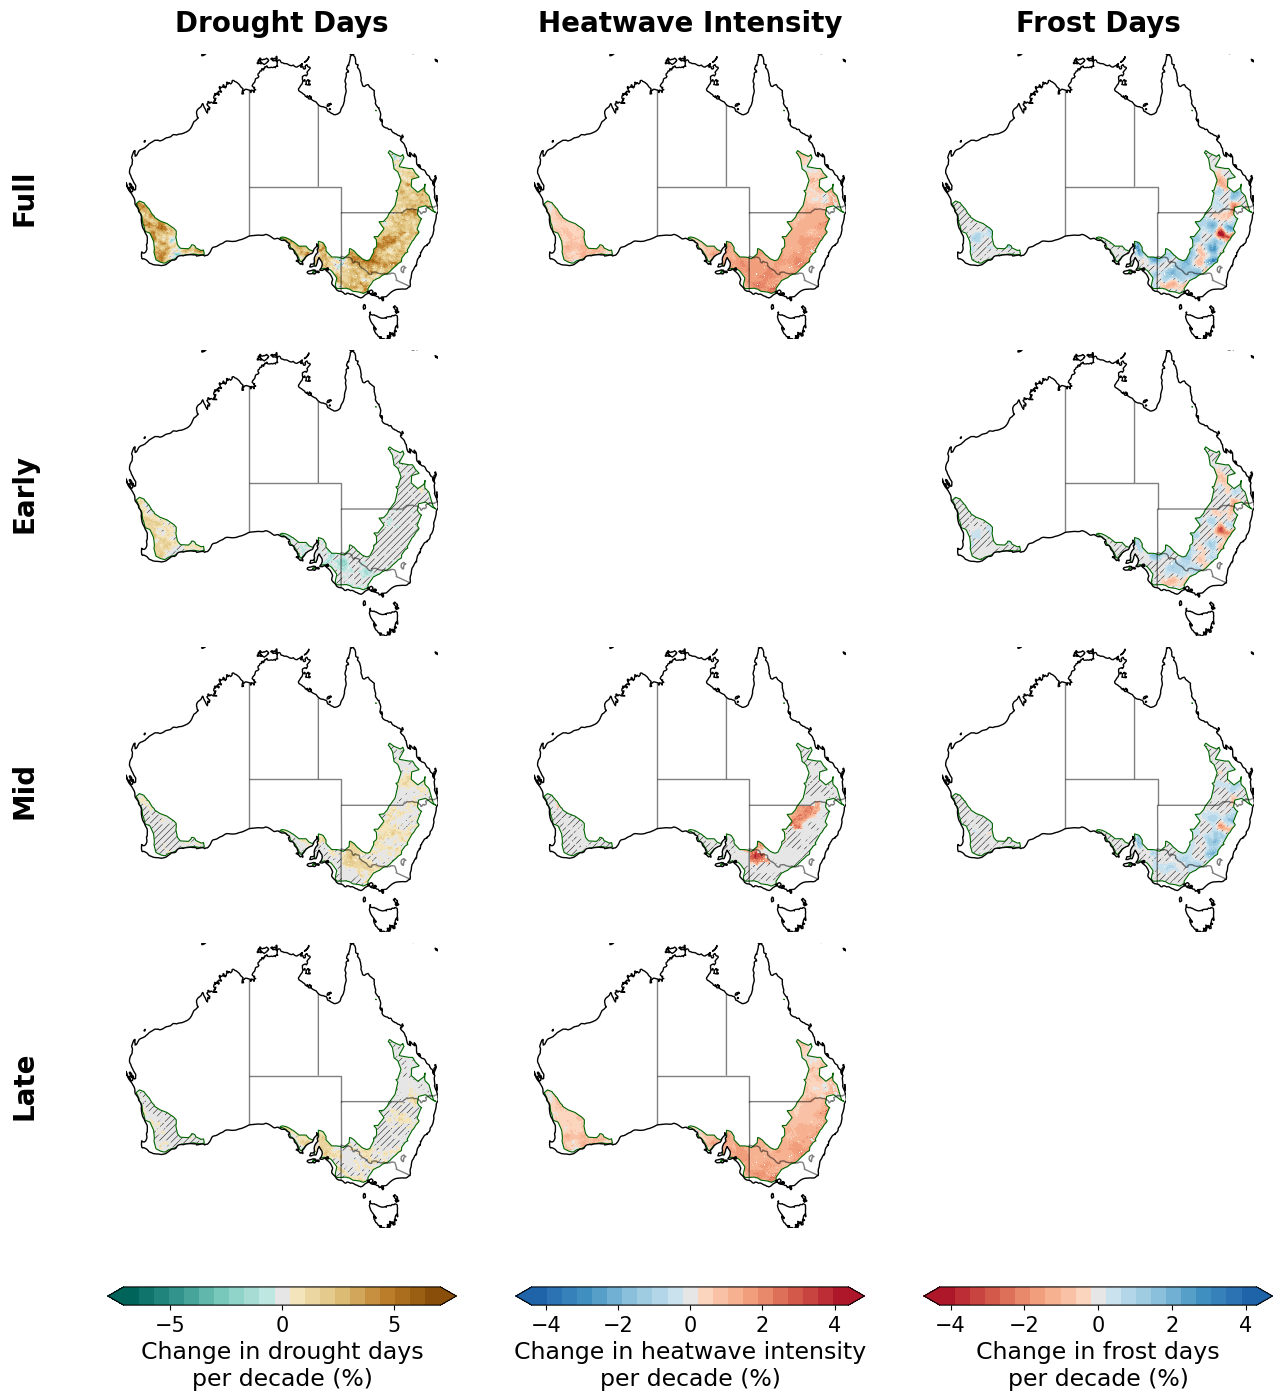

In [11]:
years = '1970-2020'
agg = None

seasons = ['growing', 'planting', 'mid', 'harvest']
season_labels = ['Full', 'Early', 'Mid', 'Late']
# season_labels = ['Late', 'Mid', 'Early', 'Full']

vars_list = ['30_day_precip_drought_sum', 'heatwave_intensity_mean', 'frost']

skip_panels = {
    ('Early', 'heatwave_intensity_mean'),
    ('Late', 'frost'),
}

var_cmap_dict = {
    'frost': create_trends_colormap('RdBu', 20, 3, norm=False),
    '30_day_precip_drought_sum': create_trends_colormap('BrBG_r', 20, 3, norm=False),
    'heatwave_intensity_mean': create_trends_colormap('RdBu_r', 20, 3, norm=False),
}

col_titles_dict = {
    'frost': 'Frost Days',
    '30_day_precip_drought_sum': 'Drought Days',
    'heatwave_intensity_mean': 'Heatwave Intensity',
}

cbar_labels_dict = {
    'frost': 'Change in frost days\nper decade (%)',
    '30_day_precip_drought_sum': 'Change in drought days\nper decade (%)',
    'heatwave_intensity_mean': 'Change in heatwave intensity\nper decade (%)',
}

TITLE_FS  = 20
CBAR_FS   = 17
TICK_FS   = 15

mpl.rcParams['hatch.linewidth'] = 0.35

wheatbelt_nc_path = '/g/data/w97/mg5624/ABS_project/ag_data/wheatbelt_shapefiles/wheatbelt.nc'
wheatbelt_shp_path = '/g/data/w97/mg5624/ABS_project/ag_data/wheatbelt_shapefiles/wheatbelt.shp'
AGCD_mask = xr.open_dataarray('/g/data/w97/mg5624/RF_project/masks/regridded_awra_awap_mask.nc')
wheat_shp = gpd.read_file(wheatbelt_shp_path)

agcd_datadir = '/g/data/zv2/agcd/v1-0-1/precip/total/r005/01day/'
grid = xr.open_dataset(agcd_datadir + 'agcd_v1-0-1_precip_total_r005_daily_2016.nc').precip.isel(time=-50)
grid = grid.reset_coords(drop=True)
crop_calendar = load_crop_growing_season_and_regrid('Wheat', grid)
seas_lens = {seas: len_of_season(crop_calendar, seas) for seas in ['growing', 'planting', 'mid', 'harvest']}

fig, axes = plt.subplots(
    len(seasons), len(vars_list),
    figsize=(5 * len(vars_list), 3.5 * len(seasons)),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# First pass: load data
all_das = {var: [] for var in vars_list}
cbar_limits = {}

for var in vars_list:
    for season, season_label in zip(seasons, season_labels):
        if (season_label, var) in skip_panels:
            all_das[var].append((season, None, None))
            continue

        trends_path = f'/g/data/w97/mg5624/ABS_project/extremes/MK_test/{season}/{var}/'
        trends_file = f'{years}_MK_yue_wang_{var}.nc'
        if agg is not None:
            trends_file = f'{years}_MK_yue_wang_{var}_agg_{agg}yr.nc'

        ds = xr.open_dataset(trends_path + trends_file)
        wheat = xr.open_dataarray(wheatbelt_nc_path).astype(int).interp_like(ds, method='nearest')
        ds = ds.where(wheat.astype(bool))
        seas_len = seas_lens[season].interp_like(ds.MK_slope, method='nearest')

        if var in ('frost', '30_day_precip_drought_sum'):
            # ds['MK_slope'] = (ds['MK_slope'] / seas_len) * 100 * 10
            ds['MK_slope'] = ds['MK_slope'] * 10
        else:
            ds['MK_slope'] = ds['MK_slope'] * 10

        da = ds.MK_slope.where(AGCD_mask)
        print(f'Max trend for {var} in {season}: {float(da.max().round(2))}')
        all_das[var].append((season, da, ds))

    valid_das = [da for _, da, _ in all_das[var] if da is not None]
    cbar_max = max(float(da.max().round(2)) for da in valid_das)
    cbar_limits[var] = (-cbar_max, cbar_max)

# Second pass: plot
col_mappables = {var: None for var in vars_list}

for row_idx, (season, season_label) in enumerate(zip(seasons, season_labels)):
    for col_idx, var in enumerate(vars_list):
        ax = axes[row_idx, col_idx]
        _, da, ds = all_das[var][row_idx]

        if (season_label, var) in skip_panels:
            ax.set_visible(False)
            continue

        trend = ds.MK_trend.where(AGCD_mask)

        # Print some trend stats
        print(f'------------ Percentage trends for {var} in {season} ------------')
        full_trend_pos = trend == 1
        full_trend_perc = ((full_trend_pos.sum() / trend.count()) * 100).values
        print(f'Full wheat belt: {full_trend_perc:.2f}%')

        WA_trend = trend.sel(lon=slice(None, 130))
        WA_trend_pos = WA_trend == 1
        WA_trend_perc = ((WA_trend_pos.sum() / WA_trend.count()) * 100).values
        print(f'WA wheat belt: {WA_trend_perc:.2f}%')

        east_trend = trend.sel(lon=slice(130, None))
        east_trend_pos = east_trend == 1
        east_trend_perc = ((east_trend_pos.sum() / east_trend.count()) * 100).values
        print(f'Eastern wheat belt: {east_trend_perc:.2f}%')

        cbar_min, cbar_max = cbar_limits[var]
        cmap = var_cmap_dict[var]

        significant = (trend != 0) | (da != 0)
        trend_masked = trend.where(~significant)

        for spine in ax.spines.values():
            spine.set_visible(False)

        im = da.plot(ax=ax, cmap=cmap, vmin=cbar_min, vmax=cbar_max, add_colorbar=False)
        trend_masked.plot.contourf(
            ax=ax, hatches=[5 * '/'], colors='none',
            levels=(0.5, 1), add_colorbar=False
        )

        ax.add_feature(cfeature.OCEAN, zorder=100, facecolor='white', edgecolor='k')
        states_provinces = NaturalEarthFeature(
            category='cultural', name='admin_1_states_provinces_lines',
            scale='50m', edgecolor='black', facecolor='none', alpha=0.5
        )
        ax.add_feature(states_provinces, linestyle='-', linewidth=1)
        wheat_shp.plot(ax=ax, facecolor='none', edgecolor='darkgreen', linewidth=0.8)

        ax.set_title('')
        ax.set_ylabel('')

        if col_mappables[var] is None:
            col_mappables[var] = (im, cbar_min, cbar_max)

# Very tight layout — minimal padding, extra bottom space for colorbars only
fig.tight_layout(rect=[0.06, 0.11, 1.0, 0.97], h_pad=0.1, w_pad=0.1)
fig.canvas.draw()

# ── Manually reposition axes into a tight grid ──────────────────────────────
# After tight_layout we override positions to pack panels closer still.
# Compute a uniform grid from the actual bounding box of all visible axes.
all_pos = [axes[r, c].get_position()
           for r in range(len(seasons))
           for c in range(len(vars_list))
           if axes[r, c].get_visible()]

grid_x0 = min(p.x0 for p in all_pos)
grid_x1 = max(p.x1 for p in all_pos)
grid_y0 = min(p.y0 for p in all_pos)
grid_y1 = max(p.y1 for p in all_pos)

n_rows = len(seasons)
n_cols = len(vars_list)

h_gap = 0.008   # fraction of figure width between panels
v_gap = 0.008   # fraction of figure height between panels

total_w = grid_x1 - grid_x0
total_h = grid_y1 - grid_y0

panel_w = (total_w - h_gap * (n_cols - 1)) / n_cols
panel_h = (total_h - v_gap * (n_rows - 1)) / n_rows

for row_idx in range(n_rows):
    for col_idx in range(n_cols):
        ax = axes[row_idx, col_idx]
        # rows go top→bottom so invert row index for y
        x0 = grid_x0 + col_idx * (panel_w + h_gap)
        y0 = grid_y1 - (row_idx + 1) * panel_h - row_idx * v_gap
        ax.set_position([x0, y0, panel_w, panel_h])

fig.canvas.draw()

# ── Column titles ── shared y just above the top-row panels
title_y = grid_y1 + 0.012
for col_idx, var in enumerate(vars_list):
    x0 = grid_x0 + col_idx * (panel_w + h_gap)
    fig.text(
        x0 + panel_w / 2, title_y,
        col_titles_dict[var],
        ha='center', va='bottom',
        fontsize=TITLE_FS, fontweight='bold'
    )

# ── Row labels ── fixed x left of column 0, y at each row centre
label_x = grid_x0 - 0.04
for row_idx, season_label in enumerate(season_labels):
    y0 = grid_y1 - (row_idx + 1) * panel_h - row_idx * v_gap
    row_center = y0 + panel_h / 2
    fig.text(
        label_x, row_center,
        season_label,
        ha='center', va='center',
        fontsize=TITLE_FS, fontweight='bold',
        rotation=90
    )

# ── Colorbars ── one per column, horizontally centered on each column
cbar_y = grid_y0 - 0.055

def add_cbar(fig, im, col_idx, panel_w, h_gap, grid_x0, cbar_y, label):
    x0 = grid_x0 + col_idx * (panel_w + h_gap)
    cbar_width = panel_w * 0.88
    cbar_x0 = x0 + (panel_w - cbar_width) / 2
    cbar_ax = fig.add_axes([cbar_x0, cbar_y, cbar_width, 0.013])
    cbar_obj = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', extend='both')
    cbar_obj.ax.tick_params(labelsize=TICK_FS)
    cbar_obj.set_label(label, fontsize=CBAR_FS)
    return cbar_ax

for col_idx, var in enumerate(vars_list):
    if col_mappables[var] is not None:
        im, _, _ = col_mappables[var]
        add_cbar(fig, im, col_idx, panel_w, h_gap, grid_x0, cbar_y, cbar_labels_dict[var])

plt.show()

In [17]:
WA_trend = trend.sel(lon=slice(None, 130))
print((WA_trend == 1).sum())
print(WA_trend.count())
WA_perc_pos = ((WA_trend == 1).sum() / WA_trend.count()) * 100
# trend['lon']
WA_perc_pos

<xarray.DataArray 'MK_trend' ()> Size: 8B
array(6706)
<xarray.DataArray 'MK_trend' ()> Size: 8B
array(8173)


<xarray.DataArray 'MK_trend' ()> Size: 8B
array(82.05065459)

/scratch/w97/mg5624/tmp/ipykernel_1143405/559095840.py:8: FutureWarning: In a future version, xarray will not decode the variable 'harvest.range' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  crop_calendar = xr.open_dataset(crop_calendar_path)
/scratch/w97/mg5624/tmp/ipykernel_1143405/559095840.py:8: FutureWarning: In a future version, xarray will not decode the variable 'plant.range' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is

Max trend for frost in planting: 1.67
Max trend for frost in mid: 2.43
Max trend for frost in growing: 4.29
Max trend for 180_day_precip_drought_sum in planting: 0.71
Max trend for 180_day_precip_drought_sum in mid: 0.0
Max trend for 180_day_precip_drought_sum in harvest: 0.0
Max trend for 180_day_precip_drought_sum in growing: 5.33
Max trend for heatwave_intensity_mean in mid: 4.39
Max trend for heatwave_intensity_mean in harvest: 3.68
Max trend for heatwave_intensity_mean in growing: 3.68


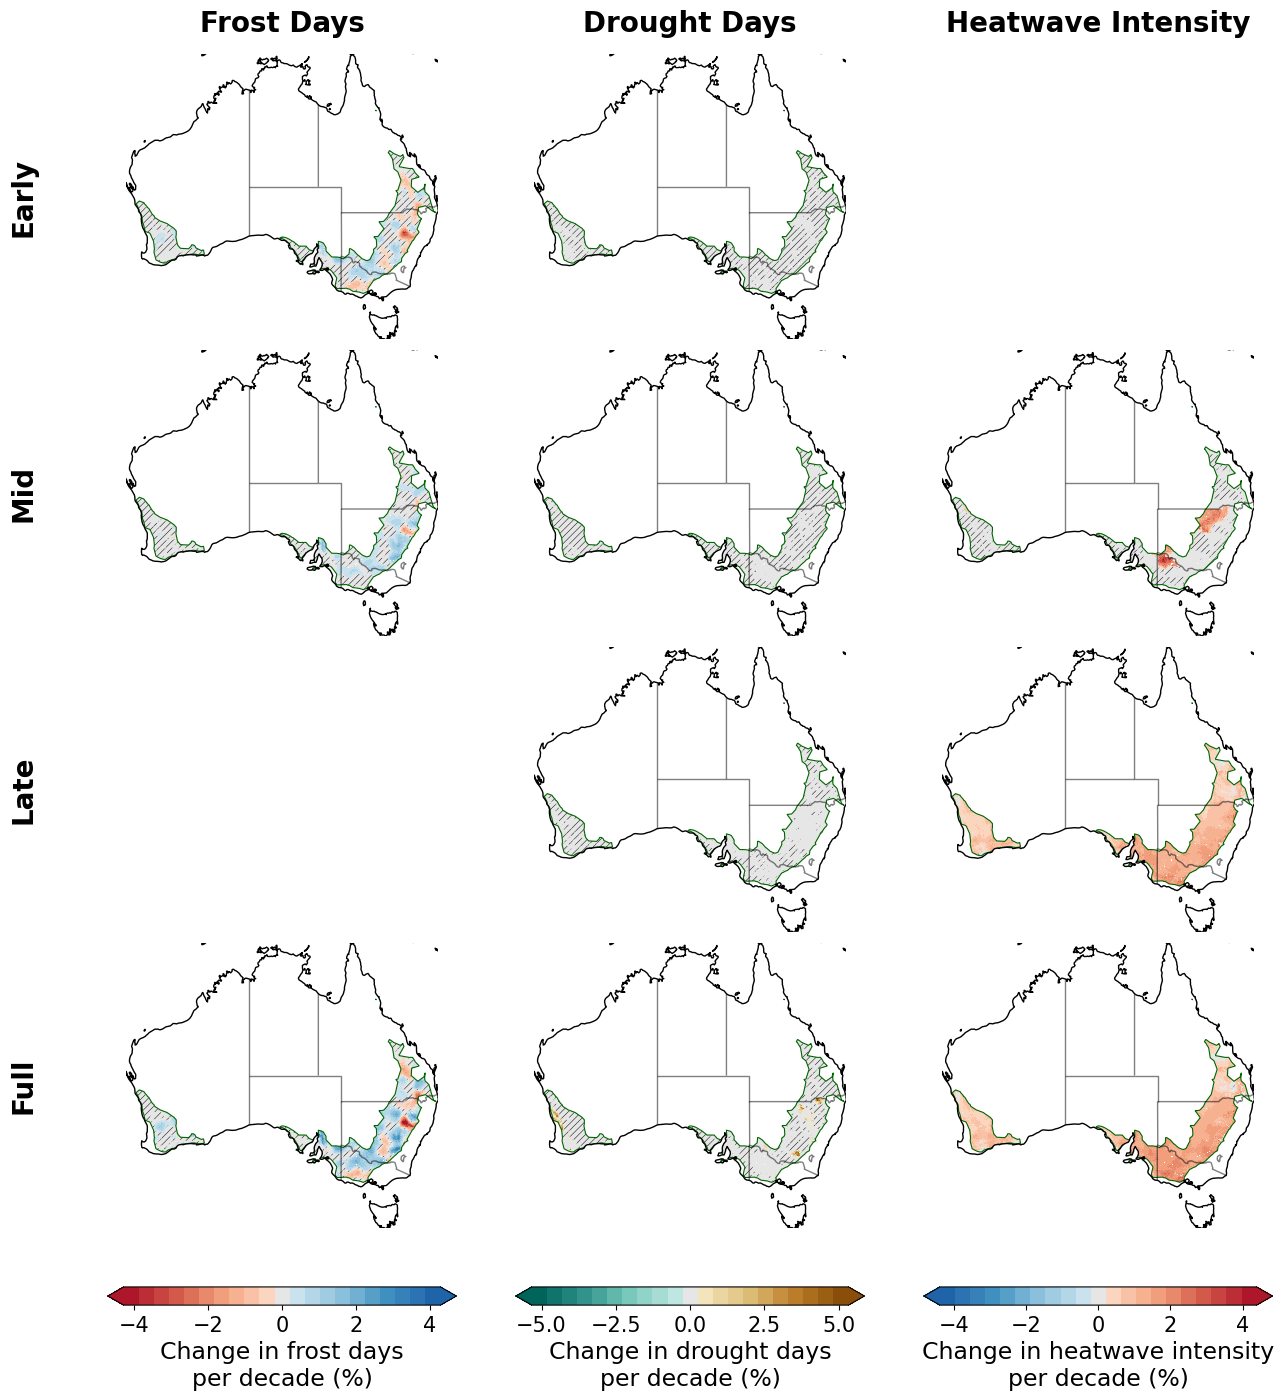

In [9]:
years = '1970-2020'
agg = None

seasons = ['planting', 'mid', 'harvest', 'growing']
season_labels = ['Early', 'Mid', 'Late', 'Full']

vars_list = ['frost', '180_day_precip_drought_sum', 'heatwave_intensity_mean']

skip_panels = {
    ('Early', 'heatwave_intensity_mean'),
    ('Late', 'frost'),
}

var_cmap_dict = {
    'frost': create_trends_colormap('RdBu', 20, 3, norm=False),
    '180_day_precip_drought_sum': create_trends_colormap('BrBG_r', 20, 3, norm=False),
    'heatwave_intensity_mean': create_trends_colormap('RdBu_r', 20, 3, norm=False),
}

col_titles_dict = {
    'frost': 'Frost Days',
    '180_day_precip_drought_sum': 'Drought Days',
    'heatwave_intensity_mean': 'Heatwave Intensity',
}

cbar_labels_dict = {
    'frost': 'Change in frost days\nper decade (%)',
    '180_day_precip_drought_sum': 'Change in drought days\nper decade (%)',
    'heatwave_intensity_mean': 'Change in heatwave intensity\nper decade (%)',
}

TITLE_FS  = 20
CBAR_FS   = 17
TICK_FS   = 15

mpl.rcParams['hatch.linewidth'] = 0.35

wheatbelt_nc_path = '/g/data/w97/mg5624/ABS_project/ag_data/wheatbelt_shapefiles/wheatbelt.nc'
wheatbelt_shp_path = '/g/data/w97/mg5624/ABS_project/ag_data/wheatbelt_shapefiles/wheatbelt.shp'
AGCD_mask = xr.open_dataarray('/g/data/w97/mg5624/RF_project/masks/regridded_awra_awap_mask.nc')
wheat_shp = gpd.read_file(wheatbelt_shp_path)

agcd_datadir = '/g/data/zv2/agcd/v1-0-1/precip/total/r005/01day/'
grid = xr.open_dataset(agcd_datadir + 'agcd_v1-0-1_precip_total_r005_daily_2016.nc').precip.isel(time=-50)
grid = grid.reset_coords(drop=True)
crop_calendar = load_crop_growing_season_and_regrid('Wheat', grid)
seas_lens = {seas: len_of_season(crop_calendar, seas) for seas in ['growing', 'planting', 'mid', 'harvest']}

fig, axes = plt.subplots(
    len(seasons), len(vars_list),
    figsize=(5 * len(vars_list), 3.5 * len(seasons)),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# First pass: load data
all_das = {var: [] for var in vars_list}
cbar_limits = {}

for var in vars_list:
    for season, season_label in zip(seasons, season_labels):
        if (season_label, var) in skip_panels:
            all_das[var].append((season, None, None))
            continue

        trends_path = f'/g/data/w97/mg5624/ABS_project/extremes/MK_test/{season}/{var}/'
        trends_file = f'{years}_MK_yue_wang_{var}.nc'
        if agg is not None:
            trends_file = f'{years}_MK_yue_wang_{var}_agg_{agg}yr.nc'

        ds = xr.open_dataset(trends_path + trends_file)
        wheat = xr.open_dataarray(wheatbelt_nc_path).astype(int).interp_like(ds, method='nearest')
        ds = ds.where(wheat.astype(bool))
        seas_len = seas_lens[season].interp_like(ds.MK_slope, method='nearest')

        if var in ('frost', '30_day_precip_drought_sum'):
            # ds['MK_slope'] = (ds['MK_slope'] / seas_len) * 100 * 10
            ds['MK_slope'] = ds['MK_slope'] * 10
        else:
            ds['MK_slope'] = ds['MK_slope'] * 10

        da = ds.MK_slope.where(AGCD_mask)
        print(f'Max trend for {var} in {season}: {float(da.max().round(2))}')
        all_das[var].append((season, da, ds))

    valid_das = [da for _, da, _ in all_das[var] if da is not None]
    cbar_max = max(float(da.max().round(2)) for da in valid_das)
    cbar_limits[var] = (-cbar_max, cbar_max)

# Second pass: plot
col_mappables = {var: None for var in vars_list}

for row_idx, (season, season_label) in enumerate(zip(seasons, season_labels)):
    for col_idx, var in enumerate(vars_list):
        ax = axes[row_idx, col_idx]
        _, da, ds = all_das[var][row_idx]

        if (season_label, var) in skip_panels:
            ax.set_visible(False)
            continue

        trend = ds.MK_trend.where(AGCD_mask)
        cbar_min, cbar_max = cbar_limits[var]
        cmap = var_cmap_dict[var]

        significant = (trend != 0) | (da != 0)
        trend_masked = trend.where(~significant)

        for spine in ax.spines.values():
            spine.set_visible(False)

        im = da.plot(ax=ax, cmap=cmap, vmin=cbar_min, vmax=cbar_max, add_colorbar=False)
        trend_masked.plot.contourf(
            ax=ax, hatches=[5 * '/'], colors='none',
            levels=(0.5, 1), add_colorbar=False
        )

        ax.add_feature(cfeature.OCEAN, zorder=100, facecolor='white', edgecolor='k')
        states_provinces = NaturalEarthFeature(
            category='cultural', name='admin_1_states_provinces_lines',
            scale='50m', edgecolor='black', facecolor='none', alpha=0.5
        )
        ax.add_feature(states_provinces, linestyle='-', linewidth=1)
        wheat_shp.plot(ax=ax, facecolor='none', edgecolor='darkgreen', linewidth=0.8)

        ax.set_title('')
        ax.set_ylabel('')

        if col_mappables[var] is None:
            col_mappables[var] = (im, cbar_min, cbar_max)

# Very tight layout — minimal padding, extra bottom space for colorbars only
fig.tight_layout(rect=[0.06, 0.11, 1.0, 0.97], h_pad=0.1, w_pad=0.1)
fig.canvas.draw()

# ── Manually reposition axes into a tight grid ──────────────────────────────
# After tight_layout we override positions to pack panels closer still.
# Compute a uniform grid from the actual bounding box of all visible axes.
all_pos = [axes[r, c].get_position()
           for r in range(len(seasons))
           for c in range(len(vars_list))
           if axes[r, c].get_visible()]

grid_x0 = min(p.x0 for p in all_pos)
grid_x1 = max(p.x1 for p in all_pos)
grid_y0 = min(p.y0 for p in all_pos)
grid_y1 = max(p.y1 for p in all_pos)

n_rows = len(seasons)
n_cols = len(vars_list)

h_gap = 0.008   # fraction of figure width between panels
v_gap = 0.008   # fraction of figure height between panels

total_w = grid_x1 - grid_x0
total_h = grid_y1 - grid_y0

panel_w = (total_w - h_gap * (n_cols - 1)) / n_cols
panel_h = (total_h - v_gap * (n_rows - 1)) / n_rows

for row_idx in range(n_rows):
    for col_idx in range(n_cols):
        ax = axes[row_idx, col_idx]
        # rows go top→bottom so invert row index for y
        x0 = grid_x0 + col_idx * (panel_w + h_gap)
        y0 = grid_y1 - (row_idx + 1) * panel_h - row_idx * v_gap
        ax.set_position([x0, y0, panel_w, panel_h])

fig.canvas.draw()

# ── Column titles ── shared y just above the top-row panels
title_y = grid_y1 + 0.012
for col_idx, var in enumerate(vars_list):
    x0 = grid_x0 + col_idx * (panel_w + h_gap)
    fig.text(
        x0 + panel_w / 2, title_y,
        col_titles_dict[var],
        ha='center', va='bottom',
        fontsize=TITLE_FS, fontweight='bold'
    )

# ── Row labels ── fixed x left of column 0, y at each row centre
label_x = grid_x0 - 0.04
for row_idx, season_label in enumerate(season_labels):
    y0 = grid_y1 - (row_idx + 1) * panel_h - row_idx * v_gap
    row_center = y0 + panel_h / 2
    fig.text(
        label_x, row_center,
        season_label,
        ha='center', va='center',
        fontsize=TITLE_FS, fontweight='bold',
        rotation=90
    )

# ── Colorbars ── one per column, horizontally centered on each column
cbar_y = grid_y0 - 0.055

def add_cbar(fig, im, col_idx, panel_w, h_gap, grid_x0, cbar_y, label):
    x0 = grid_x0 + col_idx * (panel_w + h_gap)
    cbar_width = panel_w * 0.88
    cbar_x0 = x0 + (panel_w - cbar_width) / 2
    cbar_ax = fig.add_axes([cbar_x0, cbar_y, cbar_width, 0.013])
    cbar_obj = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', extend='both')
    cbar_obj.ax.tick_params(labelsize=TICK_FS)
    cbar_obj.set_label(label, fontsize=CBAR_FS)
    return cbar_ax

for col_idx, var in enumerate(vars_list):
    if col_mappables[var] is not None:
        im, _, _ = col_mappables[var]
        add_cbar(fig, im, col_idx, panel_w, h_gap, grid_x0, cbar_y, cbar_labels_dict[var])

plt.show()

AttributeError: 'Dataset' object has no attribute 'MK_slope'

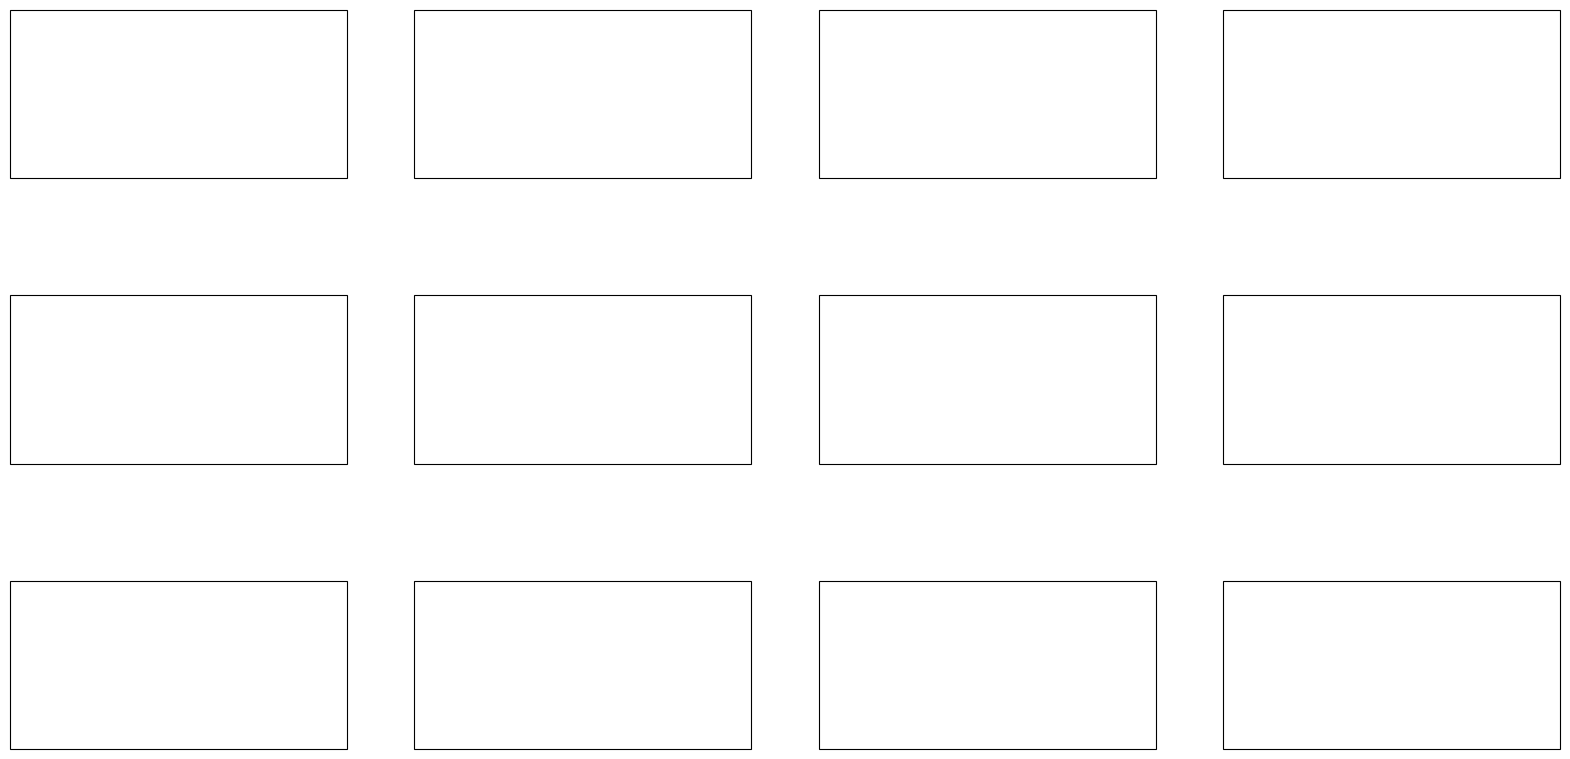

In [10]:
cbar_labels_dict = {
    'frost': 'Change in frost days\nper decade (%)',
    '30_day_precip_drought_sum': 'Change in drought\ndays per decade (%)',
    'heatwave_intensity_mean': 'Change in heatwave\nintensity per decade (%)',
}

fig, axes = plt.subplots(
    len(vars_list), len(seasons),      # ← flipped
    figsize=(5 * len(seasons), 3.5 * len(vars_list)),   # ← flipped
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# First pass: load data (same as before)
all_das = {var: [] for var in vars_list}
cbar_limits = {}

for var in vars_list:
    for season, season_label in zip(seasons, season_labels):
        if (season_label, var) in skip_panels:
            all_das[var].append((season, None, None))
            continue

        trends_path = f'/g/data/w97/mg5624/ABS_project/extremes/MK_test/{season}/{var}/'
        trends_file = f'{years}_MK_yue_wang_{var}.nc'
        if agg is not None:
            trends_file = f'{years}_MK_yue_wang_{var}_agg_{agg}yr.nc'

        ds = xr.open_dataset(trends_path + trends_file)
        wheat = xr.open_dataset(wheatbelt_nc_path).interp_like(ds, method='nearest')
        ds = ds.where(wheat.astype(bool))

        seas_len = seas_lens[season].interp_like(ds.MK_slope, method='nearest')

        if var in ('frost', '30_day_precip_drought_sum'):
            ds['MK_slope'] = (ds['MK_slope'] / seas_len) * 100 * 10
        else:
            ds['MK_slope'] = ds['MK_slope'] * 10

        da = ds.MK_slope.where(AGCD_mask)
        all_das[var].append((season, da, ds))

    valid_das = [da for _, da, _ in all_das[var] if da is not None]
    cbar_max = max(float(da.max().round(2)) for da in valid_das)
    cbar_limits[var] = (-cbar_max, cbar_max)

# Second pass: plot — rows=vars, cols=seasons
row_mappables = {var: None for var in vars_list}

for row_idx, var in enumerate(vars_list):                          # ← var is now row
    for col_idx, (season, season_label) in enumerate(zip(seasons, season_labels)):  # ← season is now col
        ax = axes[row_idx, col_idx]
        _, da, ds = all_das[var][col_idx]                          # ← index by col now

        if (season_label, var) in skip_panels:
            ax.set_visible(False)
            continue

        trend = ds.MK_trend.where(AGCD_mask)
        cbar_min, cbar_max = cbar_limits[var]
        cmap = var_cmap_dict[var]

        significant = (trend != 0) | (da != 0)
        trend_masked = trend.where(~significant)

        for spine in ax.spines.values():
            spine.set_visible(False)

        im = da.plot(ax=ax, cmap=cmap, vmin=cbar_min, vmax=cbar_max, add_colorbar=False)
        trend_masked.plot.contourf(
            ax=ax, hatches=[5 * '/'], colors='none',
            levels=(0.5, 1), add_colorbar=False
        )

        ax.add_feature(cfeature.OCEAN, zorder=100, facecolor='white', edgecolor='k')
        states_provinces = NaturalEarthFeature(
            category='cultural', name='admin_1_states_provinces_lines',
            scale='50m', edgecolor='black', facecolor='none', alpha=0.5
        )
        ax.add_feature(states_provinces, linestyle='-', linewidth=1)
        wheat_shp.plot(ax=ax, facecolor='none', edgecolor='darkgreen', linewidth=0.8)

        ax.set_title('')
        ax.set_ylabel('')

        if row_mappables[var] is None:
            row_mappables[var] = (im, cbar_min, cbar_max)

fig.tight_layout(rect=[0.12, 0.08, 1.0, 0.97], h_pad=0.1, w_pad=0.1)
fig.canvas.draw()

# ── Manually reposition axes ─────────────────────────────────────────────────
all_pos = [axes[r, c].get_position()
           for r in range(len(vars_list))
           for c in range(len(seasons))
           if axes[r, c].get_visible()]

grid_x0 = min(p.x0 for p in all_pos)
grid_x1 = max(p.x1 for p in all_pos)
grid_y0 = min(p.y0 for p in all_pos)
grid_y1 = max(p.y1 for p in all_pos)

n_rows = len(vars_list)     # ← vars are rows
n_cols = len(seasons)       # ← seasons are cols

h_gap = 0.008
v_gap = 0.008

total_w = grid_x1 - grid_x0
total_h = grid_y1 - grid_y0

panel_w = (total_w - h_gap * (n_cols - 1)) / n_cols
panel_h = (total_h - v_gap * (n_rows - 1)) / n_rows

for row_idx in range(n_rows):
    for col_idx in range(n_cols):
        ax = axes[row_idx, col_idx]
        x0 = grid_x0 + col_idx * (panel_w + h_gap)
        y0 = grid_y1 - (row_idx + 1) * panel_h - row_idx * v_gap
        ax.set_position([x0, y0, panel_w, panel_h])

fig.canvas.draw()

# ── Column titles — season labels across the top ──────────────────────────────
title_y = grid_y1 + 0.012
for col_idx, season_label in enumerate(season_labels):
    x0 = grid_x0 + col_idx * (panel_w + h_gap)
    fig.text(
        x0 + panel_w / 2, title_y,
        season_label,
        ha='center', va='bottom',
        fontsize=TITLE_FS, fontweight='bold'
    )

# ── Row labels — extreme type labels on the left ─────────────────────────────
label_x = grid_x0 - 0.04
for row_idx, var in enumerate(vars_list):
    y0 = grid_y1 - (row_idx + 1) * panel_h - row_idx * v_gap
    row_center = y0 + panel_h / 2
    fig.text(
        label_x, row_center,
        col_titles_dict[var],
        ha='center', va='center',
        fontsize=TITLE_FS, fontweight='bold',
        rotation=90
    )

# ── Colorbars — one per row (var), vertical on the far right ─────────────────
cbar_x = grid_x1 + 0.015

for row_idx, var in enumerate(vars_list):
    if row_mappables[var] is not None:
        im, _, _ = row_mappables[var]

        cbar_total_h = grid_y1 - grid_y0
        cbar_h = (cbar_total_h / n_rows) * 0.8
        # Centre the colorbar vertically within its row's band
        row_y0 = grid_y1 - (row_idx + 1) * panel_h - row_idx * v_gap
        cbar_y0 = row_y0 + (panel_h - cbar_h) / 2

        cbar_ax = fig.add_axes([cbar_x, cbar_y0, 0.013, cbar_h])
        cbar_obj = fig.colorbar(im, cax=cbar_ax, orientation='vertical', extend='both')
        cbar_obj.ax.tick_params(labelsize=TICK_FS)
        cbar_obj.set_label(cbar_labels_dict[var], fontsize=CBAR_FS)
fig.tight_layout(rect=[0.12, 0.02, 0.92, 0.97], h_pad=0.1, w_pad=0.1)
plt.show()

AttributeError: 'Dataset' object has no attribute 'MK_slope'

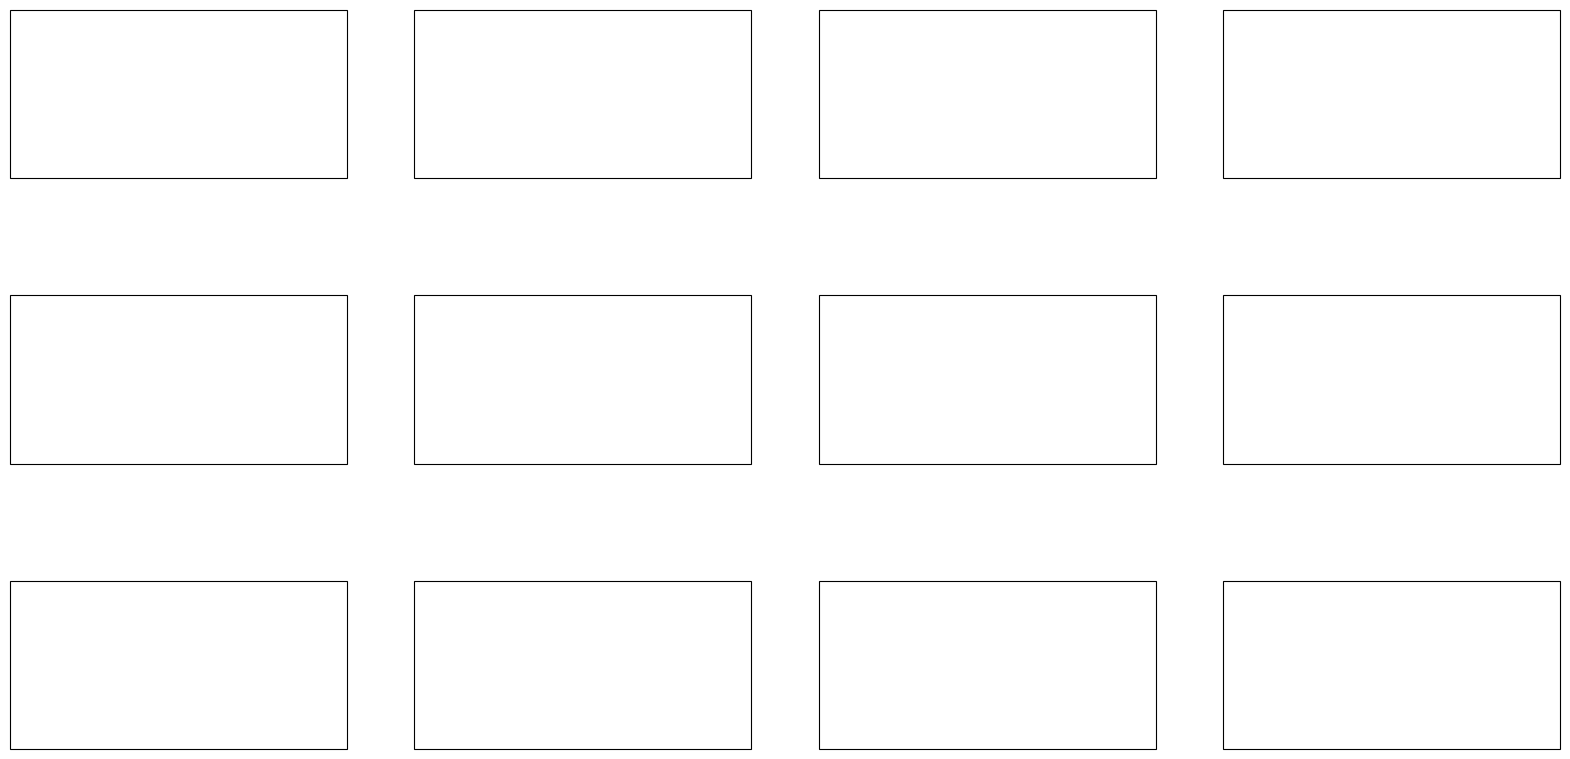

In [ ]:
cbar_labels_dict = {
    'frost': 'Change in frost days\nper decade (%)',
    '180_day_precip_drought_sum': 'Change in drought\ndays per decade (%)',
    'heatwave_intensity_mean': 'Change in heatwave\nintensity per decade (%)',
}

fig, axes = plt.subplots(
    len(vars_list), len(seasons),      # ← flipped
    figsize=(5 * len(seasons), 3.5 * len(vars_list)),   # ← flipped
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# First pass: load data (same as before)
all_das = {var: [] for var in vars_list}
cbar_limits = {}

for var in vars_list:
    for season, season_label in zip(seasons, season_labels):
        if (season_label, var) in skip_panels:
            all_das[var].append((season, None, None))
            continue

        trends_path = f'/g/data/w97/mg5624/ABS_project/extremes/MK_test/{season}/{var}/'
        trends_file = f'{years}_MK_yue_wang_{var}.nc'
        if agg is not None:
            trends_file = f'{years}_MK_yue_wang_{var}_agg_{agg}yr.nc'

        ds = xr.open_dataset(trends_path + trends_file)
        wheat = xr.open_dataset(wheatbelt_nc_path).interp_like(ds, method='nearest')
        ds = ds.where(wheat.astype(bool))

        seas_len = seas_lens[season].interp_like(ds.MK_slope, method='nearest')

        if var in ('frost', '180_day_precip_drought_sum'):
            ds['MK_slope'] = (ds['MK_slope'] / seas_len) * 100 * 10
        else:
            ds['MK_slope'] = ds['MK_slope'] * 10

        da = ds.MK_slope.where(AGCD_mask)
        all_das[var].append((season, da, ds))

    valid_das = [da for _, da, _ in all_das[var] if da is not None]
    cbar_max = max(float(da.max().round(2)) for da in valid_das)
    cbar_limits[var] = (-cbar_max, cbar_max)

# Second pass: plot — rows=vars, cols=seasons
row_mappables = {var: None for var in vars_list}

for row_idx, var in enumerate(vars_list):                          # ← var is now row
    for col_idx, (season, season_label) in enumerate(zip(seasons, season_labels)):  # ← season is now col
        ax = axes[row_idx, col_idx]
        _, da, ds = all_das[var][col_idx]                          # ← index by col now

        if (season_label, var) in skip_panels:
            ax.set_visible(False)
            continue

        trend = ds.MK_trend.where(AGCD_mask)
        cbar_min, cbar_max = cbar_limits[var]
        cmap = var_cmap_dict[var]

        significant = (trend != 0) | (da != 0)
        trend_masked = trend.where(~significant)

        for spine in ax.spines.values():
            spine.set_visible(False)

        im = da.plot(ax=ax, cmap=cmap, vmin=cbar_min, vmax=cbar_max, add_colorbar=False)
        trend_masked.plot.contourf(
            ax=ax, hatches=[5 * '/'], colors='none',
            levels=(0.5, 1), add_colorbar=False
        )

        ax.add_feature(cfeature.OCEAN, zorder=100, facecolor='white', edgecolor='k')
        states_provinces = NaturalEarthFeature(
            category='cultural', name='admin_1_states_provinces_lines',
            scale='50m', edgecolor='black', facecolor='none', alpha=0.5
        )
        ax.add_feature(states_provinces, linestyle='-', linewidth=1)
        wheat_shp.plot(ax=ax, facecolor='none', edgecolor='darkgreen', linewidth=0.8)

        ax.set_title('')
        ax.set_ylabel('')

        if row_mappables[var] is None:
            row_mappables[var] = (im, cbar_min, cbar_max)

fig.tight_layout(rect=[0.12, 0.08, 1.0, 0.97], h_pad=0.1, w_pad=0.1)
fig.canvas.draw()

# ── Manually reposition axes ─────────────────────────────────────────────────
all_pos = [axes[r, c].get_position()
           for r in range(len(vars_list))
           for c in range(len(seasons))
           if axes[r, c].get_visible()]

grid_x0 = min(p.x0 for p in all_pos)
grid_x1 = max(p.x1 for p in all_pos)
grid_y0 = min(p.y0 for p in all_pos)
grid_y1 = max(p.y1 for p in all_pos)

n_rows = len(vars_list)     # ← vars are rows
n_cols = len(seasons)       # ← seasons are cols

h_gap = 0.008
v_gap = 0.008

total_w = grid_x1 - grid_x0
total_h = grid_y1 - grid_y0

panel_w = (total_w - h_gap * (n_cols - 1)) / n_cols
panel_h = (total_h - v_gap * (n_rows - 1)) / n_rows

for row_idx in range(n_rows):
    for col_idx in range(n_cols):
        ax = axes[row_idx, col_idx]
        x0 = grid_x0 + col_idx * (panel_w + h_gap)
        y0 = grid_y1 - (row_idx + 1) * panel_h - row_idx * v_gap
        ax.set_position([x0, y0, panel_w, panel_h])

fig.canvas.draw()

# ── Column titles — season labels across the top ──────────────────────────────
title_y = grid_y1 + 0.012
for col_idx, season_label in enumerate(season_labels):
    x0 = grid_x0 + col_idx * (panel_w + h_gap)
    fig.text(
        x0 + panel_w / 2, title_y,
        season_label,
        ha='center', va='bottom',
        fontsize=TITLE_FS, fontweight='bold'
    )

# ── Row labels — extreme type labels on the left ─────────────────────────────
label_x = grid_x0 - 0.04
for row_idx, var in enumerate(vars_list):
    y0 = grid_y1 - (row_idx + 1) * panel_h - row_idx * v_gap
    row_center = y0 + panel_h / 2
    fig.text(
        label_x, row_center,
        col_titles_dict[var],
        ha='center', va='center',
        fontsize=TITLE_FS, fontweight='bold',
        rotation=90
    )

# ── Colorbars — one per row (var), vertical on the far right ─────────────────
cbar_x = grid_x1 + 0.015

for row_idx, var in enumerate(vars_list):
    if row_mappables[var] is not None:
        im, _, _ = row_mappables[var]

        cbar_total_h = grid_y1 - grid_y0
        cbar_h = (cbar_total_h / n_rows) * 0.8
        # Centre the colorbar vertically within its row's band
        row_y0 = grid_y1 - (row_idx + 1) * panel_h - row_idx * v_gap
        cbar_y0 = row_y0 + (panel_h - cbar_h) / 2

        cbar_ax = fig.add_axes([cbar_x, cbar_y0, 0.013, cbar_h])
        cbar_obj = fig.colorbar(im, cax=cbar_ax, orientation='vertical', extend='both')
        cbar_obj.ax.tick_params(labelsize=TICK_FS)
        cbar_obj.set_label(cbar_labels_dict[var], fontsize=CBAR_FS)
fig.tight_layout(rect=[0.12, 0.02, 0.92, 0.97], h_pad=0.1, w_pad=0.1)
plt.show()

----------growing-----------
Coordinates:
  * time     (time) datetime64[ns] 576B 1951-01-01 1952-01-01 ... 2022-01-01
  * lat      (lat) float32 3kB -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon      (lon) float32 4kB 112.0 112.1 112.1 112.2 ... 156.1 156.2 156.2
no trend


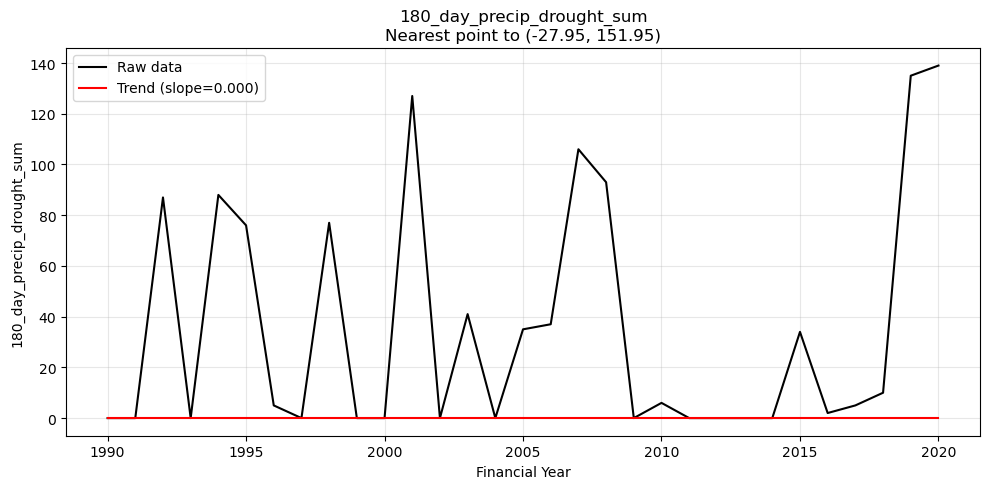

----------planting-----------
Coordinates:
  * time     (time) datetime64[ns] 576B 1951-01-01 1952-01-01 ... 2022-01-01
  * lat      (lat) float32 3kB -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon      (lon) float32 4kB 112.0 112.1 112.1 112.2 ... 156.1 156.2 156.2
no trend


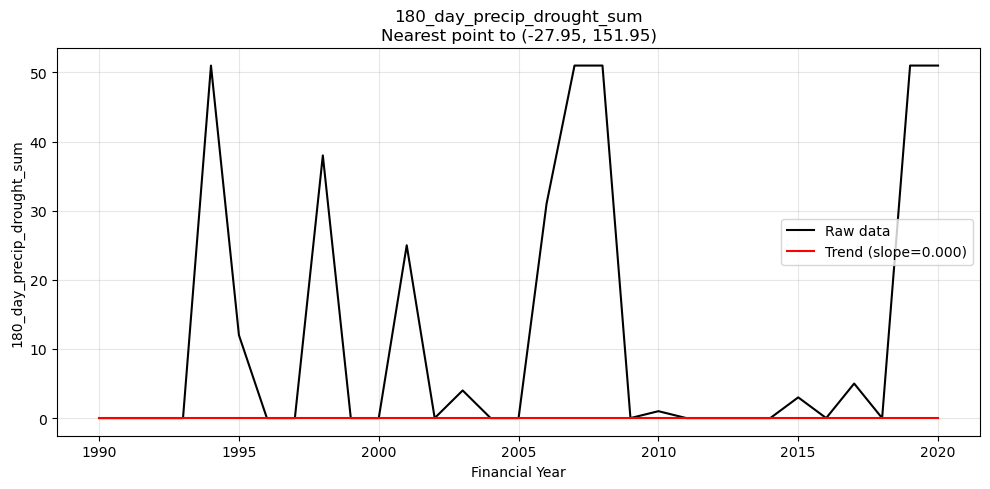

----------mid-----------
Coordinates:
  * time     (time) datetime64[ns] 576B 1951-01-01 1952-01-01 ... 2022-01-01
  * lat      (lat) float32 3kB -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon      (lon) float32 4kB 112.0 112.1 112.1 112.2 ... 156.1 156.2 156.2
no trend


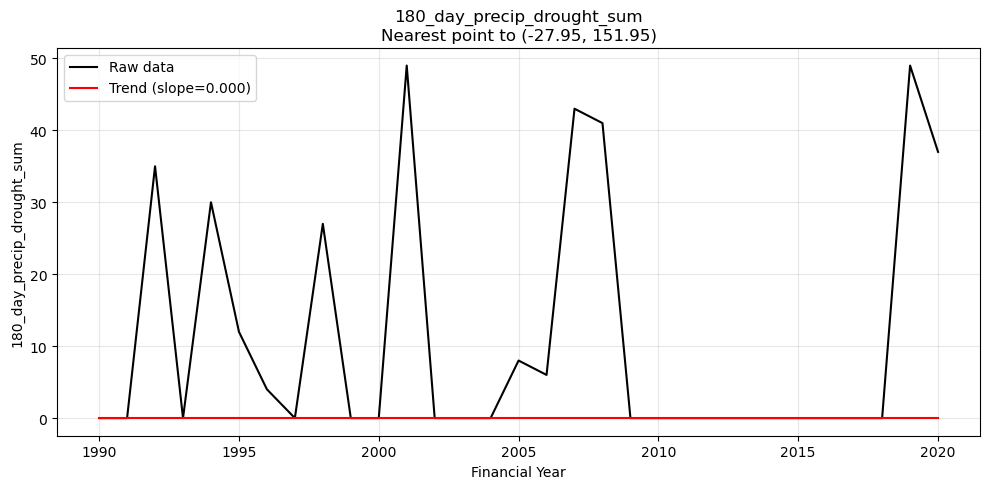

----------harvest-----------
Coordinates:
  * time     (time) datetime64[ns] 576B 1951-01-01 1952-01-01 ... 2022-01-01
  * lat      (lat) float32 3kB -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon      (lon) float32 4kB 112.0 112.1 112.1 112.2 ... 156.1 156.2 156.2
no trend


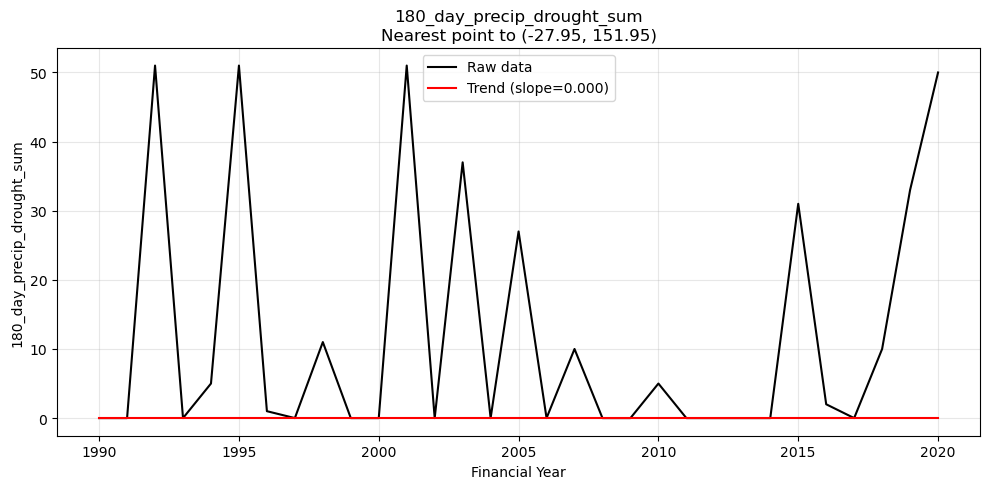

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymannkendall as mk

target_lat = -25.95
target_lon = 149.95

base_path = "/g/data/w97/mg5624/ABS_project/extremes/FY_aggregated/"

for var in [
    "180_day_precip_drought",   # base name of the file
    # '180_day_precip_drought_intensity'
]:
    file = f"{base_path}{var}_FY_agg_1950-2021.nc"
    ds = xr.open_dataset(file)
    ds = ds.assign_coords(time=pd.to_datetime(ds.time.astype(str), format="%Y"))
    # These are the actual variable names inside the fil
    subvars = {
        "180_day_precip_drought": "180_day_precip_drought_sum",   # base name of the file
        "180_day_precip_drought_intensity": "180_day_precip_drought_intensity_mean"
    }
    sv = subvars[var]
    for season in [
        'growing', 
        'planting', 
        'mid', 
        'harvest'
    ]:
        print(f'----------{season}-----------')
        var_name = f'{season}_seas_{sv}'
        # --- 1. Extract nearest grid point ---
        # 
        da = ds[var_name].sel(lat=target_lat, lon=target_lon, method="nearest").sel(time=slice('1990', '2020'))
    
        # --- 2. Extract time series ---
        print(ds[var_name].coords)
        
        years = da["time"].dt.year.values
        values = da.values

        # --- 3. Mann–Kendall + Sen slope ---
        mk_result = mk.original_test(values)
        print(mk_result.trend)
        slope = mk_result.slope
        intercept = values[0] - slope * years[0]

        trend_line = intercept + slope * years

        # --- 4. Plot ---
        plt.figure(figsize=(10, 5))
        plt.plot(years, values, label="Raw data", color="black")
        plt.plot(years, trend_line, label=f"Trend (slope={slope:.3f})", color="red")

        sig = " (p<0.05)" if mk_result.p < 0.05 else ""

        plt.title(f"{sv}\nNearest point to ({target_lat}, {target_lon}){sig}")
        plt.xlabel("Financial Year")
        plt.ylabel(sv)
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()
